In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

import itertools
from collections import defaultdict


   




In [36]:

def plot_dry_bulk_tonnage_by_year(data: pd.DataFrame, port_name: str):
    """
    Plot Dry Bulk TOTAL tonnage by year for a given port.

    Parameters
    ----------
    data : pd.DataFrame
        Full port dataset (e.g., Port_Data_20260107.csv)
    port_name : str
        Exact port name as it appears in the Port_Name column
    """

    # --- Filter to selected port ---
    port_df = data[data["Port_Name"] == port_name]

    if port_df.empty:
        raise ValueError(f"No data found for port: {port_name}")

    # --- Filter to Dry Bulk / Total ---
    df_plot = port_df[
        (port_df["Cargo Type"] == "DRY BULK") &
        (port_df["Trade Type"] == "TOTAL")
    ].copy()

    if df_plot.empty:
        raise ValueError(f"No DRY BULK TOTAL data for port: {port_name}")

    # --- Clean and scale volume to millions ---
    df_plot["Volume_M"] = (
        df_plot["Volume"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
        / 1e6
    )

    df_plot = df_plot.sort_values("Reporting Year")

    # --- Tick formatter (adds 'M') ---
    def millions_formatter(x, pos):
        return f"{x:.0f}M"

    # --- Plot ---
    plt.figure()
    plt.bar(df_plot["Reporting Year"], df_plot["Volume_M"])
    plt.xlabel("Reporting Year")
    plt.ylabel("Dry Bulk Tonnage (Short Tons)")
    plt.title(f"Dry Bulk Tonnage by Year - {port_name} ")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))
    plt.xticks(df_plot["Reporting Year"])

    plt.show()


def plot_total_tonnage_by_year(data: pd.DataFrame, port_name: str):
    """
    Plot TOTAL TONNAGE (TOTAL trade type) by year for a given port.

    Parameters
    ----------
    data : pd.DataFrame
        Full port dataset (e.g., Port_Data_20260107.csv)
    port_name : str
        Exact port name as it appears in the Port_Name column
    """

    # --- Filter to selected port ---
    port_df = data[data["Port_Name"] == port_name]

    if port_df.empty:
        raise ValueError(f"No data found for port: {port_name}")

    # --- Filter to Total Tonnage / Total ---
    df_plot = port_df[
        (port_df["Cargo Type"] == "TOTAL TONNAGE") &
        (port_df["Trade Type"] == "TOTAL")
    ].copy()

    if df_plot.empty:
        raise ValueError(f"No TOTAL TONNAGE data for port: {port_name}")

    # --- Clean and scale volume to millions ---
    df_plot["Volume_M"] = (
        df_plot["Volume"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
        / 1e6
    )

    df_plot = df_plot.sort_values("Reporting Year")

    # --- Tick formatter (adds 'M') ---
    def millions_formatter(x, pos):
        return f"{x:.0f}M"

    # --- Plot ---
    plt.figure()
    plt.bar(df_plot["Reporting Year"], df_plot["Volume_M"])
    plt.xlabel("Reporting Year")
    plt.ylabel("Total Tonnage (Short Tons)")
    plt.title(f"{port_name} – Total Tonnage by Year")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))
    plt.xticks(df_plot["Reporting Year"])

    plt.show()




def plot_container_teus_by_year(data: pd.DataFrame, port_name: str):
    """
    Plot total container TEUs by year for a given port.
    """

    # Filter to selected port
    port_df = data[data["Port_Name"] == port_name]
    if port_df.empty:
        raise ValueError(f"No data found for port: {port_name}")

    # Filter to container totals
    df_plot = port_df[
        (port_df["Cargo Type"] == "CONTAINER") &
        (port_df["Trade Type"] == "TOTAL")
    ].copy()

    if df_plot.empty:
        raise ValueError(f"No CONTAINER TOTAL data for port: {port_name}")

    # Clean TEU volume
    df_plot["TEUs"] = (
        df_plot["Volume"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    # Sort by year (one-liner, as it should be)
    df_plot = df_plot.sort_values("Reporting Year")

    # Tick formatter
    def teus_formatter(x, pos):
        return f"{int(x):,}"

    # Plot
    plt.figure()
    plt.bar(df_plot["Reporting Year"], df_plot["TEUs"])
    plt.xlabel("Reporting Year")
    plt.ylabel("Container Volume (TEUs)")
    plt.title(f"{port_name} – Container TEUs by Year")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(teus_formatter))
    plt.xticks(df_plot["Reporting Year"])

    plt.show()



import pandas as pd
import matplotlib.pyplot as plt
import textwrap


def plot_top5_commodities_pie(data: pd.DataFrame, port_name: str):
    """
    Plot a pie chart of TOP 5 COMMODITIES by total tonnage
    aggregated across the entire period of record for a given port.

    - Excludes TOTAL rows
    - Uses absolute tonnage labels (Short Tons)
    - Wrapped legend labels
    - Large, right-hand legend
    """

    # --- Filter to port + TOP 5 COMMODITIES ---
    df_port = data[
        (data["Port_Name"] == port_name) &
        (data["Cargo Type"] == "TOP 5 COMMODITIES")
    ].copy()

    if df_port.empty:
        raise ValueError(f"No TOP 5 COMMODITIES data for port: {port_name}")

    # --- Clean volume ---
    df_port["Volume"] = (
        df_port["Volume"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    # --- Remove TOTAL rows explicitly ---
    df_port = df_port[df_port["Trade Type"].str.upper() != "TOTAL"]

    # --- Aggregate across all years ---
    totals = (
        df_port
        .groupby("Trade Type", as_index=False)["Volume"]
        .sum()
        .sort_values("Volume", ascending=False)
    )

    # --- Wrap legend labels at word boundaries ---
    def wrap_label(text, width=28):
        return "\n".join(textwrap.wrap(text, width=width))

    wrapped_labels = [wrap_label(t) for t in totals["Trade Type"]]

    # --- Formatter for absolute tonnage labels ---
    def tonnage_autopct(values):
        def _formatter(pct):
            total = values.sum()
            val = int(round(pct * total / 100.0))
            return f"{val:,}"
        return _formatter

    # --- Plot ---
    plt.figure(figsize=(9, 6))

    wedges, texts, autotexts = plt.pie(
        totals["Volume"],
        labels=None,
        autopct=tonnage_autopct(totals["Volume"]),
        startangle=90,
        textprops={"fontsize": 9}
    )

    for autotext in autotexts:
        autotext.set_fontsize(8)

    plt.legend(
        wedges,
        wrapped_labels,
        title="Commodity",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        fontsize=13,
        title_fontsize=14,
        frameon=True
    )

    plt.title(f"{port_name} – Top 5 Commodities (All Years Combined)")
    plt.tight_layout()
    plt.show()


def plot_top5_commodities_pie(data: pd.DataFrame, port_name: str):
    """
    Plot a pie chart of TOP 5 COMMODITIES by total tonnage,
    aggregated across the entire period of record for a given port.

    Visual standards (locked):
    - No TOTAL slice
    - Absolute tonnage labels outside the pie
    - Color-matched labels
    - Collision-aware label placement
    - Wrapped legend labels
    - Large legend with enlarged color bars
    - Legend positioned safely to the right
    """

    # --- Filter to port + TOP 5 COMMODITIES ---
    df_port = data[
        (data["Port_Name"] == port_name) &
        (data["Cargo Type"] == "TOP 5 COMMODITIES")
    ].copy()

    if df_port.empty:
        raise ValueError(f"No TOP 5 COMMODITIES data for port: {port_name}")

    # --- Clean volume ---
    df_port["Volume"] = (
        df_port["Volume"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    # --- Remove TOTAL rows explicitly ---
    df_port = df_port[df_port["Trade Type"].str.upper() != "TOTAL"]

    # --- Aggregate across all years ---
    totals = (
        df_port
        .groupby("Trade Type", as_index=False)["Volume"]
        .sum()
        .sort_values("Volume", ascending=False)
    )

    # --- Wrap legend labels at word boundaries ---
    def wrap_label(text, width=28):
        return "\n".join(textwrap.wrap(text, width=width))

    wrapped_labels = [wrap_label(t) for t in totals["Trade Type"]]

    # --- Plot ---
    plt.figure(figsize=(9, 6))

    wedges, _ = plt.pie(
        totals["Volume"],
        startangle=90,
        labels=None,
        radius=1.0
    )

    # --- External numeric labels (final tuned placement) ---
    for wedge, value in zip(wedges, totals["Volume"]):
        angle = (wedge.theta2 + wedge.theta1) / 2.0
        rad = np.deg2rad(angle)

        slice_fraction = (wedge.theta2 - wedge.theta1) / 360.0
        r = 1.09 if slice_fraction < 0.15 else 1.04

        x = r * np.cos(rad)
        y = r * np.sin(rad)

        ha = "left" if x > 0 else "right"

        plt.text(
            x,
            y,
            f"{value:,.0f}",
            ha=ha,
            va="center",
            fontsize=12,
            fontweight="bold",
            color=wedge.get_facecolor()
        )

    # --- Legend (final placement & sizing) ---
    plt.legend(
        wedges,
        wrapped_labels,
        title="Commodity",
        loc="center left",
        bbox_to_anchor=(1.15, 0.5),
        fontsize=13,
        title_fontsize=14,
        frameon=True,
        handlelength=2.5,
        handleheight=1.5
    )

    # --- Title ---
    plt.title(
        f"{port_name} – Top 5 Commodities (All Years Combined)",
        fontsize=17,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()



def build_commodity_style_map(df, top_k_elite=10):
    """
    Build a global commodity → style map using co-occurrence weight.
    
    Elite commodities (top_k_elite by co-occurrence weight) receive:
      - unique base hues
      - no hatch

    All other commodities:
      - reuse hues with collision minimization
      - must have a hatch

    Returns:
        dict: commodity -> style dict
    """
    
    NON_COMMODITY_VALUES = {
        "TOTAL", "IMPORTS", "EXPORTS", "DOMESTIC",
        "FOREIGN", "EMPTY", "Container"
    }

    df = df[~df["Trade Type"].isin(NON_COMMODITY_VALUES)].copy()

    # Commodities per port
    port_to_commodities = (
        df.groupby("Port_Name")["Trade Type"]
        .apply(lambda x: sorted(set(x)))
    )

    commodities = sorted({c for lst in port_to_commodities for c in lst})

    # Co-occurrence matrix
    co_occurrence = defaultdict(lambda: defaultdict(int))
    for lst in port_to_commodities:
        for a, b in itertools.combinations(lst, 2):
            co_occurrence[a][b] += 1
            co_occurrence[b][a] += 1

    co_weight = {c: sum(co_occurrence[c].values()) for c in commodities}

    # Elite commodities
    elite = sorted(
        commodities, key=lambda c: co_weight[c], reverse=True
    )[:top_k_elite]

    BASE_COLORS = list(plt.get_cmap("tab10").colors[:top_k_elite])
    HATCHES = ["//", "\\\\", "xx", "..", "oo", "++", "--", "**", "||", "OO", "XX"]

    style_map = {}

    # Assign elite (solid, unique hues)
    for i, c in enumerate(elite):
        style_map[c] = {
            "color_idx": i,
            "color": BASE_COLORS[i],
            "hatch": "",
            "edgecolor": "black",
            "elite": True,
        }

    # Assign remaining (hatched)
    for c in [x for x in commodities if x not in elite]:
        best_color = None
        best_cost = float("inf")

        for color_idx in range(top_k_elite):
            cost = sum(
                w for n, w in co_occurrence[c].items()
                if n in style_map and style_map[n]["color_idx"] == color_idx
            )
            if cost < best_cost:
                best_cost = cost
                best_color = color_idx

        style_map[c] = {
            "color_idx": best_color,
            "color": BASE_COLORS[best_color],
            "hatch": HATCHES[abs(hash(c)) % len(HATCHES)],
            "edgecolor": "black",
            "elite": False,
        }

    return style_map


def plot_port_top_commodities(
    df,
    port_name,
    style_map,
    top_n=6,
    figsize=(9, 5),
):
    """
    Plot Top-N commodities for a single port using a precomputed style map.
    """
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter

    NON_COMMODITY_VALUES = {
        "TOTAL", "IMPORTS", "EXPORTS", "DOMESTIC",
        "FOREIGN", "EMPTY", "Container"
    }

    df = df[~df["Trade Type"].isin(NON_COMMODITY_VALUES)].copy()

    df["Volume"] = (
        df["Volume"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    df_port = df[df["Port_Name"] == port_name]

    totals = (
        df_port.groupby("Trade Type", as_index=False)["Volume"]
        .sum()
        .sort_values("Volume", ascending=False)
        .head(top_n)
    )

    totals["Volume_M"] = totals["Volume"] / 1e6

    def millions_formatter(x, pos):
        return f"{int(x)}M"

    plt.figure(figsize=figsize)

    for _, row in totals.iterrows():
        style = style_map[row["Trade Type"]]
        plt.barh(
            row["Trade Type"],
            row["Volume_M"],
            color=style["color"],
            hatch=style["hatch"],
            edgecolor=style["edgecolor"],
        )

    plt.xlabel("Total Tonnage (Million Short Tons)")
    plt.gca().xaxis.set_major_formatter(FuncFormatter(millions_formatter))
    plt.title(
        f"{port_name} – Top {top_n} Commodities (All Years)",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()



def plot_vessel_movement_types(
    df,
    port_name,
    figsize=(9, 5),
    scale_to_millions=False,
):
    """
    Plot vessel / movement type tonnage for a single port using
    color-blind-safe colors.

    Movement types plotted:
      - Container
      - Other Freight
      - Other Freight Barge
      - Dry Bulk
      - Dry Bulk Barge
    """
    # Ensure volume is numeric
    df = df.copy()
    df["Volume"] = (
        df["Volume"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    # Vessel / movement categories
    movement_types = [
        "Container",
        "Other Freight",
        "Other Freight Barge",
        "Dry Bulk",
        "Dry Bulk Barge",
    ]

    # Filter to port and movement types
    df_port = df[
        (df["Port_Name"] == port_name) &
        (df["Trade Type"].isin(movement_types))
    ]

    if df_port.empty:
        raise ValueError(f"No movement-type data found for port: {port_name}")

    # Aggregate
    totals = (
        df_port
        .groupby("Trade Type", as_index=False)["Volume"]
        .sum()
        .sort_values("Volume", ascending=True)
    )

    # Optional scaling
    if scale_to_millions:
        totals["PlotVolume"] = totals["Volume"] / 1e6
        x_label = "Total Tonnage (Million Units)"
    else:
        totals["PlotVolume"] = totals["Volume"]
        x_label = "Total Tonnage (Native Units)"

    # Color-blind-safe palette (Okabe–Ito)
    colors = {
        "Container": "#0072B2",           # Blue
        "Other Freight": "#009E73",       # Green
        "Other Freight Barge": "#D55E00", # Vermillion
        "Dry Bulk": "#E69F00",            # Orange
        "Dry Bulk Barge": "#CC79A7",      # Purple
    }

    bar_colors = totals["Trade Type"].map(colors)

    # Plot
    plt.figure(figsize=figsize)
    plt.barh(
        totals["Trade Type"],
        totals["PlotVolume"],
        color=bar_colors,
        edgecolor="black",
    )

    # Axis formatting
    if scale_to_millions:
        plt.gca().xaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f"{int(x)}M")
        )

    plt.xlabel(x_label)
    plt.title(
        f"{port_name} – Vessel / Movement Type Breakdown",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()



In [10]:
df=pd.read_csv("Port_Data_20260107.csv")

In [6]:
df['Port_Name'].unique()

array(['Alaska, AK Port of', 'Baltimore, MD', 'Beaumont, TX',
       'Boston, MA', 'Cincinnati-Northern KY, Ports of',
       'Cleveland-Cuyahoga Port, OH', 'Corpus Christi, TX',
       'Duluth-Superior, MN and WI', 'Tacoma, WA',
       'Greater Baton Rouge, LA Port of', 'Gulfport, MS',
       "Honolulu, O'ahu, HI", 'Houston Port Authority, TX',
       'Huntington-Tristate, KY, OH, WV',
       'Illinois Waterway Ports and Terminals Port Statistical Area, IL',
       'Jacksonville, FL', 'Kalama, WA Port of',
       'Lake Charles Harbor District, LA', 'Long Beach, CA Port of',
       'Longview, WA Port of', 'Los Angeles, CA Port of',
       'Mid-America Port Commission', 'Mid-Ohio Valley Port, OH and WV',
       'Mobile, AL', 'New Bourbon Port, MO', 'New Orleans, LA',
       'New York, NY & NJ', 'Northern Indiana, IN', 'Oakland, CA Port of',
       'Philadelphia Regional Port, PA', 'Pittsburgh, PA Port of',
       'Plaquemines Port District, LA', 'Port Arthur, TX',
       'Port Everglade

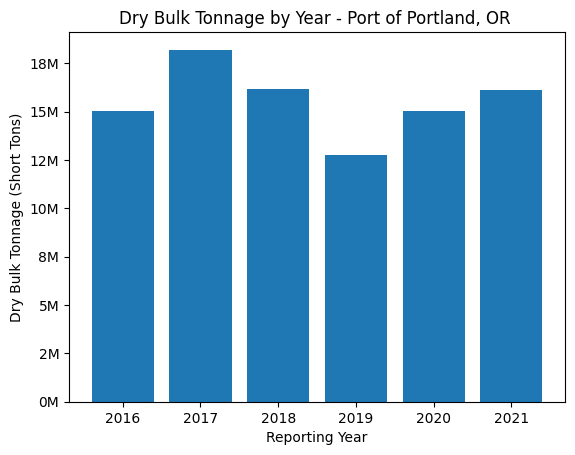

In [21]:
plot_dry_bulk_tonnage_by_year(df, "Port of Portland, OR")


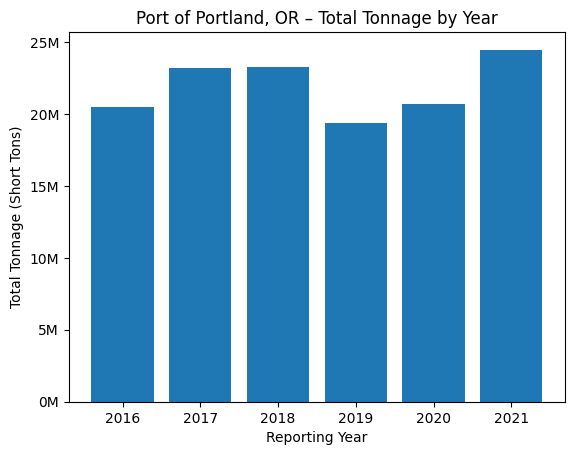

In [20]:
plot_total_tonnage_by_year(df, "Port of Portland, OR")

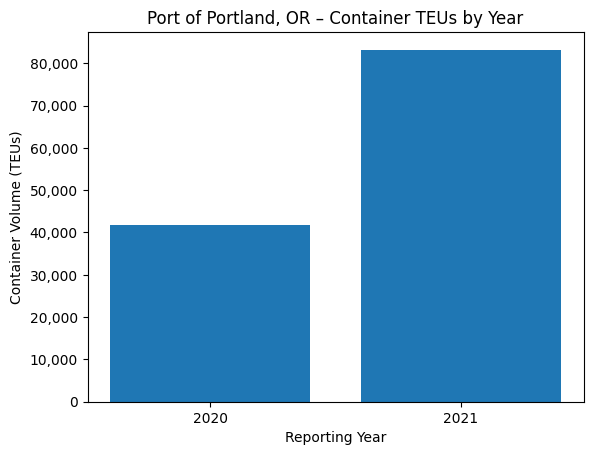

In [23]:
plot_container_teus_by_year(df, "Port of Portland, OR")

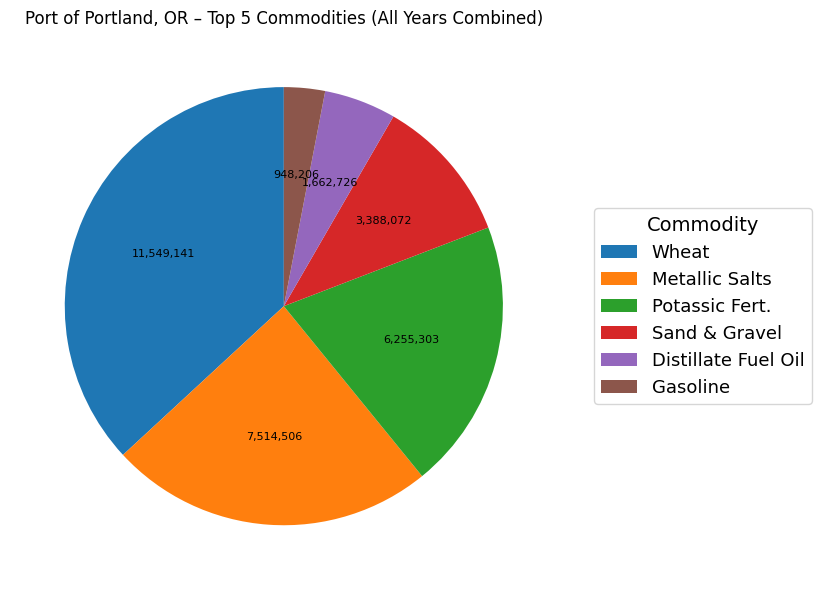

In [25]:
plot_top5_commodities_pie(df, "Port of Portland, OR")

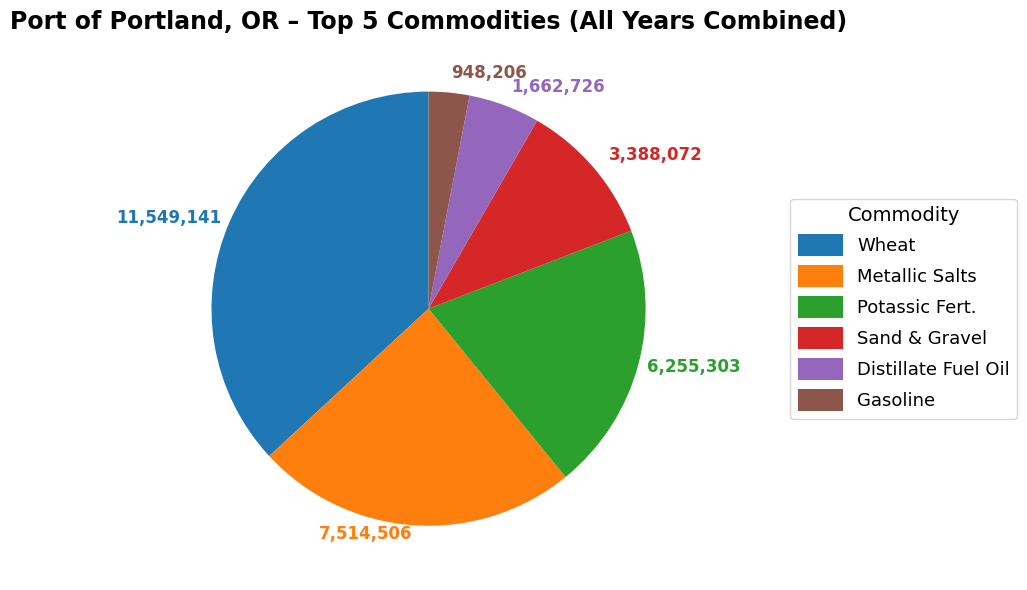

In [29]:
plot_top5_commodities_pie(df, "Port of Portland, OR")

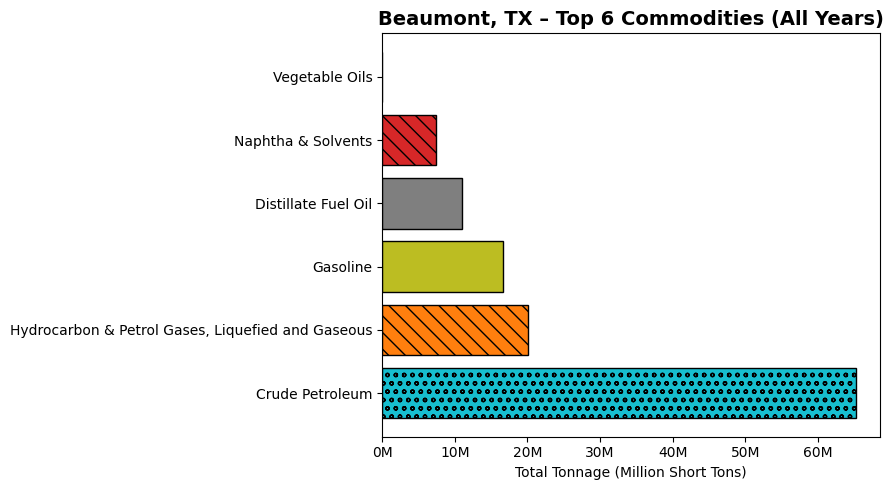

In [35]:
style_map = build_commodity_style_map(df)

plot_port_top_commodities(
    df,
    port_name='Beaumont, TX',
    style_map=style_map,
    top_n=6
)

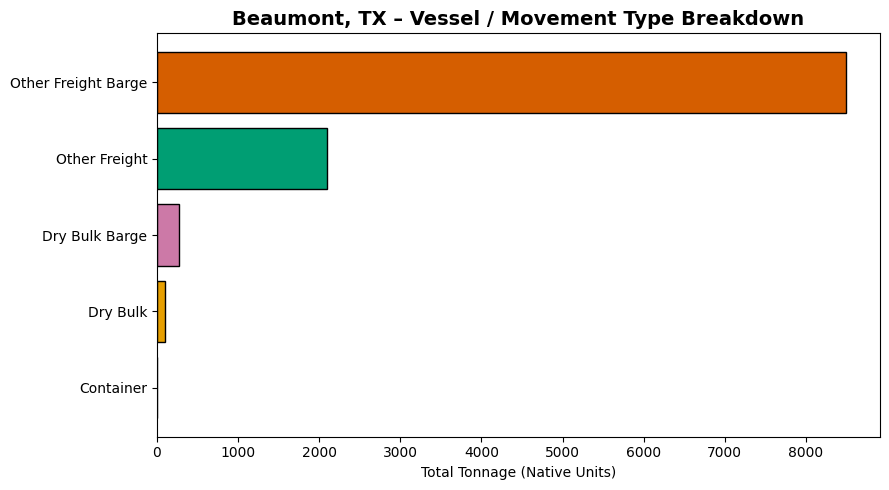

In [37]:
plot_vessel_movement_types( df,
    port_name='Beaumont, TX')